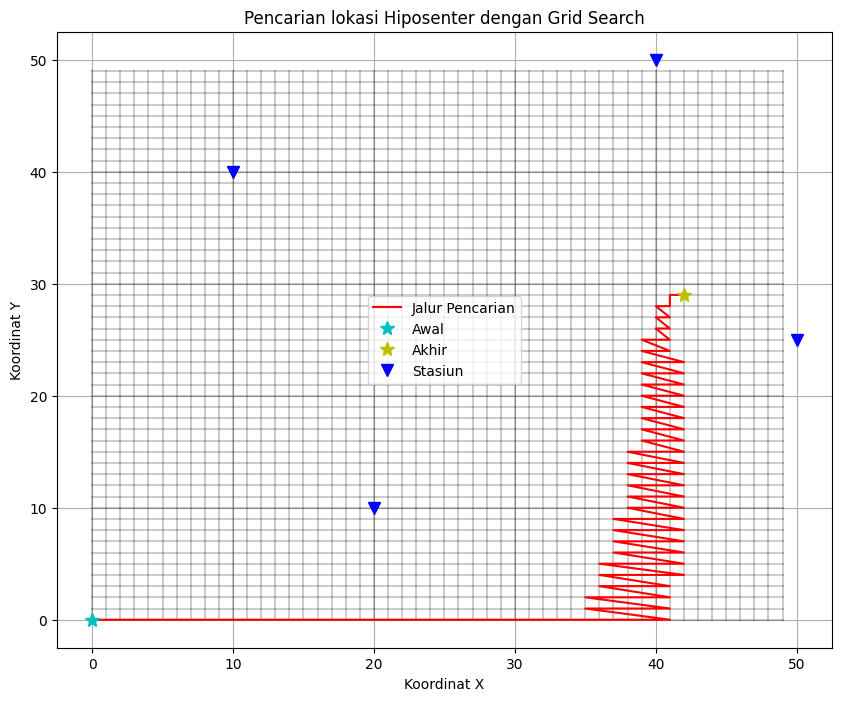

Koordinat X Hiposenter Terbaik: 42
Koordinat Y Hiposenter Terbaik: 29
Misfit Terbaik: 0.3892487158369358
Jumlah Iterasi: 176


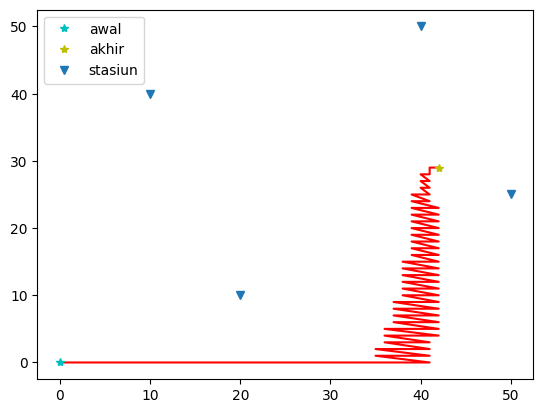

Text(0.5, 1.0, 'kurva RMS VS N Iterasi')

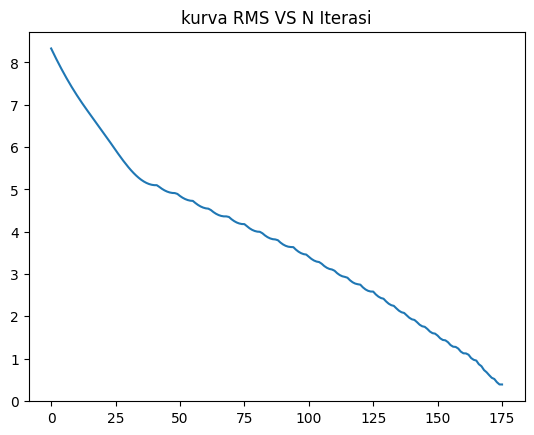

In [7]:
# Grid Search
import numpy as np                              # Import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 # Import library matplotlib untuk visualisasi grafik
import copy                                     # Import library copy untuk menyalin objek
from numpy.linalg import inv                    # Import fungsi invers matriks dari numpy.linalg

Vavg = 4                                        # Kecepatan rata-rata gelombang seismik
tobs = [7.1,1.8,5.0,7.9]                       # Data waktu observasi
tobs = np.reshape(tobs,(len(tobs),1))          # Mengubah array observasi menjadi matriks kolom
Xsts = [20,50,40,10]                           # Koordinat X stasiun
Ysts = [10,25,50,40]                           # Koordinat Y stasiun

# Definisi ruang model
L = 1                                           # Interval grid pencarian
X0 = np.arange(0,50,L)                         # Membuat grid koordinat X
Y0 = np.arange(0,50,L)                         # Membuat grid koordinat Y

#Looping
P = 10                                          # Nilai awal misfit minimum
HypoX = []                                      # List untuk menyimpan koordinat X hiposenter
HypoY = []                                      # List untuk menyimpan koordinat Y hiposenter
erms = []                                       # List untuk menyimpan RMS error

for i in range(len(Y0)):                        # Perulangan grid pada arah Y
    for j in range(len(X0)):                    # Perulangan grid pada arah X
        Dt = []                                 # List untuk menyimpan selisih waktu kuadrat
        for k in range(len(Xsts)):              # Perulangan untuk setiap stasiun
            tcal = (np.sqrt((X0[j]-Xsts[k])**2 + (Y0[i]-Ysts[k])**2) / Vavg) # Menghitung waktu tempuh teoritis
            Dt.append((tobs[k]-tcal)**2)        # Menghitung selisih kuadrat waktu
        
        misfit = np.sqrt(np.mean(Dt))           # Menghitung RMS misfit        
        if misfit < P:                          # Seleksi model dengan misfit terkecil
            HypoX.append(X0[j])                 # Menyimpan koordinat X terbaik
            HypoY.append(Y0[i])                 # Menyimpan koordinat Y terbaik
            erms.append(misfit)                 # Menyimpan nilai RMS error
            P = misfit                          # Update nilai misfit minimum
        else:
            pass                                # Jika tidak memenuhi syarat maka dilewati

# plot hasil
plt.figure(figsize=(10, 8))                    # Menentukan ukuran figure

# Membuat grid vertikal
for x in X0:
    plt.plot([x, x], [Y0[0], Y0[-1]], 'k-', alpha=0.2)  # Plot garis grid vertikal
# Membuat grid horizontal
for y in Y0:
    plt.plot([X0[0], X0[-1]], [y, y], 'k-', alpha=0.2)  # Plot garis grid horizontal

# Plot jalur pencarian
plt.plot(HypoX, HypoY, '-r', label='Jalur Pencarian')   # Menampilkan jalur pencarian
plt.plot(HypoX[0], HypoY[0], '*c', markersize=10, label='Awal')  # Titik awal
plt.plot(HypoX[-1], HypoY[-1], '*y', markersize=10, label='Akhir')  # Titik akhir

# Plot stasiun
plt.plot(Xsts, Ysts, 'v', markersize=8, color='blue', label='Stasiun')  # Posisi stasiun

# Label grafik
plt.xlabel('Koordinat X')                      # Label sumbu X
plt.ylabel('Koordinat Y')                      # Label sumbu Y
plt.title('Pencarian lokasi Hiposenter dengan Grid Search')  # Judul grafik
plt.legend()                                   # Menampilkan legenda
plt.grid(True)                                 # Menampilkan grid utama
plt.show()                                     # Menampilkan grafik

# Output hasil akhir
print('Koordinat X Hiposenter Terbaik:', HypoX[-1])  # Output koordinat X terbaik
print('Koordinat Y Hiposenter Terbaik:', HypoY[-1])  # Output koordinat Y terbaik
print('Misfit Terbaik:', P)                    # Output nilai misfit minimum
print('Jumlah Iterasi:', len(HypoX))           # Output jumlah iterasi pencarian

# Plot jalur pencarian sederhana
plt.plot(HypoX, HypoY, '-r')                   # Plot jalur pencarian
plt.plot(HypoX[0], HypoY[0], '*c', label='awal')  # Plot titik awal
plt.plot(HypoX[len(HypoX)-1], HypoY[len(HypoY)-1], '*y', label='akhir')  # Plot titik akhir
plt.plot(Xsts, Ysts, 'v', label='stasiun')     # Plot posisi stasiun
plt.xlabel('')                                 # Label kosong sumbu X
plt.legend()                                   # Menampilkan legenda
plt.show()                                     # Menampilkan grafik

# Plot RMS terhadap iterasi
plt.plot(erms)                                 # Plot RMS error
plt.title('kurva RMS VS N Iterasi')            # Judul grafik RMS

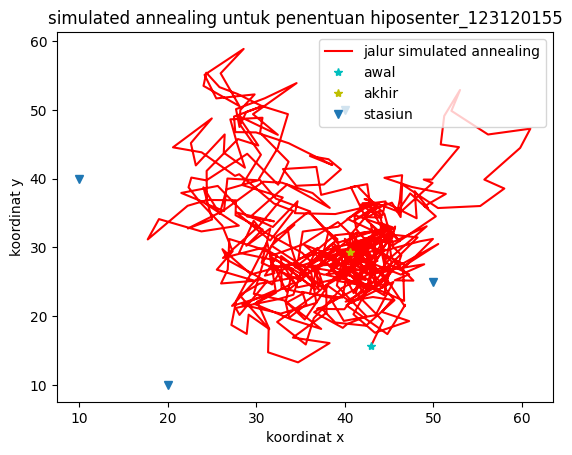

final hypocenter: 40.588558562020715 29.302980643386462
final misfit: 0.5170166235587335
iterations: 494


In [8]:
#simulated annealing
import numpy as np                              #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 #import library matplotlib untuk visualisasi grafik

#data observasi
vavg = 4                                        #kecepatan rata-rata gelombang dalam medium
tobs = [7.1,1.8,5.0,7.9]                       #waktu tiba gelombang p yang diamati di setiap stasiun
xsts = [20,50,40,10]                           #koordinat x stasiun
ysts = [10,25,50,40]                           #koordinat y stasiun

#parameter simulated annealing
xmin, ymin = 0,0                               #batas bawah ruang pencarian
xmax, ymax = 50,50                             #batas atas ruang pencarian
t0 = 100                                       #temperatur awal
tmin = 0.1                                     #temperatur minimum
alpha = 0.99                                   #faktor pendinginan (cooling rate)
max_iter = 1000                                #maksimum iterasi

#inisialisasi varibale
x = np.random.uniform(xmin,xmax)               #koordinat x awal (acak)
y = np.random.uniform(ymin,ymax)               #koordinat y awal (acak)
hypox, hypoy = [x], [y]                        #list untuk menyimpan koordinat hiposenter

#algoritma simulated annealing
t = t0                                         #inisialisasi temperatur awal
for k in range(max_iter):                      #perulangan simulated annealing
    #perturbasi solusi saat ini
    dx = np.random.uniform(-1,1)*(xmax-xmin)/10   #perubahan acak koordinat x
    dy = np.random.uniform(-1,1)*(ymax-ymin)/10   #perubahan acak koordinat y
    x1 = x + dx                                #koordinat x baru
    y1 = y + dy                                #koordinat y baru

    #hitung misfit untuk solusi saat ini dan solusi baru
    e = np.mean([(tobs[i]-np.sqrt((x-xsts[i])**2+(y-ysts[i])**2)/vavg)**2 for i in range(len(xsts))])   #misfit solusi saat ini
    e1 = np.mean([(tobs[i]-np.sqrt((x1-xsts[i])**2 + (y1-ysts[i])**2)/vavg)**2 for i in range (len(xsts))]) #misfit solusi baru
    de = e1 - e                                #selisih misfit antara solusi baru dan lama

    #terima atau tolak solusi baru
    if de < 0 or np.exp(-de/t) > np.random.rand():  #kriteria penerimaan solusi 
        x,y = x1,y1                            #update solusi      
        hypox.append(x)                        #simpan koordinat x hiposenter
        hypoy.append(y)                        #simpan koordinat y hiposenter

    #pendinginan(cooling schedule)
    t *= alpha                                 #mengurangi temperatur  
    if t < tmin:                               #menghentikan iterasi jika temperatur minimum tercapai
        break

#plot hasil simulated annealing
plt.plot(hypox, hypoy, '-r', label='jalur simulated annealing')  #plot jalur pencarian
plt.plot(hypox[0], hypoy[0], '*c', label='awal')  #plot titik awal
plt.plot(hypox[-1], hypoy[-1], '*y', label='akhir')  #plot titik akhir
plt.plot(xsts, ysts, 'v', label='stasiun')     #plot posisi stasiun
plt.xlabel('koordinat x')                      #label sumbu x
plt.ylabel('koordinat y')                      #label sumbu y
plt.legend()                                   #menampilkan legenda
plt.title('simulated annealing untuk penentuan hiposenter_123120155')  #judul grafik
plt.show()                                     #menampilkan grafik

print('final hypocenter:', hypox[-1], hypoy[-1])  #output koordinat hiposenter akhir
print('final misfit:', e1)                     #output nilai misfit akhir
print('iterations:', len(hypox))               #output jumlah iterasi

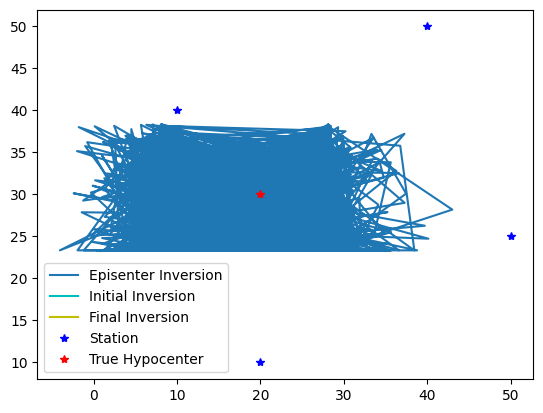

In [14]:
#simulated annealing
import numpy as np                              #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 #import library matplotlib untuk visualisasi grafik
import copy                                     #import library copy untuk menyalin data
from numpy.linalg import inv                    #import fungsi invers matriks dari numpy.linalg

Xtrue = 20                                      #koordinat X hiposenter sebenarnya
Ytrue = 30                                      #koordinat Y hiposenter sebenarnya

Vavg = 4                                        #kecepatan rata-rata gelombang
tobs = []                                       #list untuk menyimpan waktu observasi

Xsts = [20, 50, 40, 10]                        #koordinat X stasiun
Ysts = [10, 25, 50, 40]                        #koordinat Y stasiun

# Generate data observasi
for i in range(len(Xsts)):                     #perulangan untuk setiap stasiun    
    noise = np.random.rand()                   #membuat noise acak
    r = np.sqrt((Xsts[i] - Xtrue)**2 + 
                (Ysts[i] - Ytrue)**2) #menghitung jarak hiposenter ke stasiun
    tobs.append((r / Vavg) + noise)            #menghitung waktu observasi dengan noise

# Batas model
Xmin = 0                                       #batas minimum koordinat X
Ymin = 0                                       #batas minimum koordinat Y
Xmax = 50                                      #batas maksimum koordinat X
Ymax = 50                                      #batas maksimum koordinat Y

# Model awal
X = (Xmin + np.random.rand()) * (Xmax - Xmin)  #membuat model awal koordinat X acak
Y = (Ymin + np.random.rand()) * (Ymax - Ymin)  #membuat model awal koordinat Y acak

# Hitung tcal awal
tcal = []                                      #list untuk menyimpan waktu teoritis
for i in range(len(Xsts)):                     #perulangan untuk setiap stasiun
    tcal.append(np.sqrt((X - Xsts[i])**2 + (Y - Ysts[i])**2) / Vavg)     #menghitung waktu teoritis awal

# Misfit awal
dt = []                                        #list untuk menyimpan residual waktu
E = []                                         #list untuk menyimpan error kuadrat
for i in range(len(tcal)):                     #perulangan menghitung error
    dt.append(tobs[i] - tcal[i])              #menghitung selisih waktu observasi dan teoritis
    E.append(dt[i] * dt[i])                   #menghitung error kuadrat

T = copy.deepcopy(E)                           #menyalin error awal sebagai temperatur awal

k = 0                                          #counter iterasi temperatur
U = 0                                          #counter kondisi berhenti
Umax = 100                                     #maksimum iterasi tanpa penerimaan solusi
Lmax = 100                                     #maksimum iterasi lokal
Amin = 100                                     #minimum solusi diterima

HypoX = []                                     #list koordinat X hiposenter
HypoY = []                                     #list koordinat Y hiposenter

while U < Umax:                                #perulangan utama simulated annealing
    Lk = 0                                     #counter iterasi lokal
    Ak = 0                                     #counter solusi diterima

    while Lk < Lmax and Ak < Amin:             #perulangan pencarian lokal
        Urand = np.random.rand()               #bilangan acak
        ydX = np.sign(Urand - 0.5) * np.mean(T) * (
            ((1 + (1 / np.mean(T))) ** abs(2 * Urand - 1)) - 1)#menghitung perturbasi acak arah X
        
        dX = ydX * (Xmax - Xmin) / 2           #menghitung perubahan koordinat X

        if abs(dX) < 10:                       #membatasi perubahan minimum
            dX = (abs(dX) / dX) * 10           #mengatur perubahan minimum sebesar 10
        
        Urand = np.random.rand()               #bilangan acak baru
        ydY = np.sign(Urand - 0.5) * np.mean(T) * (
            ((1 + (1 / np.mean(T))) ** abs(2 * Urand - 1)) - 1) #menghitung perturbasi acak arah Y
        
        dY = ydY * (Ymax - Ymin) / 2           #menghitung perubahan koordinat Y

        if abs(dY) < 10:                       #membatasi perubahan minimum
            dY = (abs(dY) / dY) * 10           #mengatur perubahan minimum sebesar 10

        Urand = np.random.rand()               #membuat bilangan acak
        
        X1 = X + dX                            #model baru koordinat X
        Y1 = Y + dY                            #model baru koordinat Y

        # Hitung tcal baru
        for i in range(len(Xsts)):             #perulangan menghitung waktu teoritis baru
            tcal[i] = np.sqrt((X1 - Xsts[i])**2 + (Y1 - Ysts[i])**2) / Vavg  #menghitung waktu teoritis baru

        # Hitung error baru
        de = []                                #list residual baru      
        for i in range(len(tcal)):             #perulangan menghitung residual
            de.append(tobs[i] - tcal[i])      #menghitung residual baru

        E1 = np.asmatrix(de) * np.asmatrix(de).T #menghitung error baru
        dE = np.asmatrix(np.asmatrix(E1) - np.asmatrix(E))  #menghitung perubahan error
                                                

        Lk = Lk + 1                            #menambah iterasi lokal

        # Seleksi model
        if np.mean(dE) <= 0:                   #jika error baru lebih kecil     
            HypoX.append(X1)                   #menyimpan koordinat X baru
            HypoY.append(Y1)                   #menyimpan koordinat Y baru    
            E = E1                             #update error
            Ak = Ak + 1                        #menambah jumlah solusi diterima
        else:
            P = np.exp(-np.mean(dE) / np.mean(T)) #menghitung probabilitas penerimaan
            R = np.random.rand()               #membuat bilangan acak

            if R < np.mean(P):                 #jika solusi diterima
                HypoX.append(X1)               #menyimpan koordinat X baru
                HypoY.append(Y1)               #menyimpan koordinat Y baru
                E = E1                         #update error
                Ak = Ak + 1                    #menambah jumlah solusi diterima

    # Update temperatur
    if Ak == 0:                                #jika tidak ada solusi diterima
        U = U + 1                              #menambah counter penghentian
    else:
        U = 0                                  #reset counter penghentian

    T = np.asmatrix(np.asmatrix(T) * 0.99)     #menurunkan temperatur
    k = k + 1                                  #menambah iterasi temperatur

# Plot hasil
plt.plot(HypoX, HypoY, label='Episenter Inversion')  #plot jalur inversi
plt.plot(HypoX[0], HypoY[0], 'c', label='Initial Inversion')#plot titik awal inversi                                                
plt.plot(HypoX[-1], HypoY[-1], 'y', label='Final Inversion')#plot titik akhir inversi
plt.plot(Xsts, Ysts, '*b', label='Station')     #plot posisi stasiun
plt.plot(Xtrue, Ytrue, '*r', label='True Hypocenter')#plot hiposenter sebenarnya
                                                 
plt.legend()                                    #menampilkan legenda
plt.show()                                      #menampilkan grafik